# 📊 Telco Customer Churn Prediction


---

## 🎯 Problem Statement

A fictional telecommunications company serving **7,043 customers in California (Q3)** is losing subscribers to competitors. This is called **churn** — when a customer stops using the company's services.

### Why Does This Matter?
- Acquiring a new customer costs **5–7x more** than retaining an existing one.
- Even a **5% reduction in churn** can increase profits by **25–95%**.
- Identifying at-risk customers **before they leave** allows the business to intervene proactively.

### What This Notebook Does:
1. ✅ Loads and explores customer data
2. ✅ Cleans and prepares the data for analysis
3. ✅ Builds machine learning models to predict which customers will churn
4. ✅ Identifies the key reasons why customers leave
5. ✅ Provides actionable business recommendations

---


---
# 🔧 Step 1: Environment Setup
### Connecting to Google Drive and Loading Tools

Before we can analyze data, we need to:
1. Connect this notebook to your Google Drive (where the data is stored)
2. Load the software libraries (tools) needed for analysis

In [11]:
# ── Standard library ─────────────────────────────────────────────────────────
import os
import logging
import warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, Dict, List

# ── Core Data Libraries ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

# ── Visualization Libraries ───────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine Learning Libraries ────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    roc_curve, average_precision_score, ConfusionMatrixDisplay
)

# ── Optional: XGBoost ─────────────────────────────────────────────────────────
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    logger.info("XGBoost is available.")
except ImportError:
    XGBOOST_AVAILABLE = False
    logger.warning("XGBoost not found. Install via: pip install xgboost")

# ── Chart Style ───────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print("All libraries loaded successfully!")


All libraries loaded successfully!


📋 **What this step does:**
- Loads all the software tools needed for our analysis — think of these as specialized calculators and chart-makers
- **pandas** helps us read and work with spreadsheet-style data
- **matplotlib / seaborn** create the charts and graphs you'll see in this notebook
- **sklearn** contains the machine learning algorithms that will predict which customers will churn
- **XGBoost** is an advanced prediction algorithm (bonus tool if available)

In [12]:
# ── Project Configuration (single source of truth) ───────────────────────────
@dataclass
class Config:
    """Central configuration - change parameters here, they propagate everywhere."""

    # Data
    file_name: str = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
    drive_folder: str = '/content/drive/MyDrive/Telco_Churn/'
    random_state: int = 42
    test_size: float = 0.20

    # Model hyper-parameters
    lr_max_iter: int = 1000
    rf_n_estimators: int = 200
    rf_max_depth: int = 15
    rf_min_samples_leaf: int = 5
    xgb_n_estimators: int = 300
    xgb_learning_rate: float = 0.05
    xgb_max_depth: int = 5

    # Risk thresholds (churn probability %)
    risk_low_thresh: float = 30.0
    risk_med_thresh: float = 60.0

    # Business assumptions for ROI
    retention_cost_per_customer: float = 50.0
    retention_rate_target: float = 0.20

    data_path: Path = field(init=False)

    def __post_init__(self):
        if os.path.exists('/content/drive'):
            self.data_path = Path(self.drive_folder) / self.file_name
        else:
            self.data_path = Path(self.file_name)

CFG = Config()
print(f"Config initialised. Data path: {CFG.data_path}")

Config initialised. Data path: /content/drive/MyDrive/Telco_Churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


📋 **What this step does:**
- Defines **all configurable parameters in one place** - file paths, model settings, risk thresholds, and business assumptions
- This is a production best-practice: changing a parameter here automatically propagates everywhere in the notebook
- In Colab the notebook auto-detects Google Drive; locally it reads from the working directory


In [13]:
# ── Mount Google Drive (only runs inside Colab) ───────────────────────────────
try:
    import google.colab  # noqa: F401
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive connected successfully!")
except ImportError:
    print("Not running in Colab - skipping Drive mount.")
    print("Make sure the CSV is in the current working directory.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive connected successfully!


---
# 🔍 Step 2: Data Understanding
### Getting Familiar With Our Customer Data

Before jumping into analysis, we need to understand what data we have. This is like reading through a report before presenting it — essential groundwork.

In [14]:
# ── Load the Dataset ──────────────────────────────────────────────────────────
def load_data(path: Path) -> pd.DataFrame:
    """Load the CSV with basic path validation."""
    if not path.exists():
        raise FileNotFoundError(
            f"Dataset not found at: {path}\n"
            "Please upload the file or update CFG.file_name."
        )
    df = pd.read_csv(path)
    logger.info(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns from '{path.name}'")
    return df

df = load_data(CFG.data_path)
print(f"Dataset loaded successfully!")
print(f"Total customers in dataset: {df.shape[0]:,}")
print(f"Total data columns (features): {df.shape[1]}")


Dataset loaded successfully!
Total customers in dataset: 7,043
Total data columns (features): 21


📋 **What this step does:**
- Opens and reads the customer data file from your Google Drive
- Loads all 7,043 customer records into memory so we can analyze them
- Confirms how many customers and data fields (columns) we're working with
- This is the foundation of the entire analysis — without this, nothing else works

In [15]:
print("=" * 60)
print("SAMPLE OF CUSTOMER DATA (First 5 rows)")
print("=" * 60)
df.head()


SAMPLE OF CUSTOMER DATA (First 5 rows)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


📋 **What this step does:**
- Shows the first 5 rows of our customer database as a table
- Each row is one customer; each column is a piece of information about them
- Helps confirm the data loaded correctly and looks as expected
- Business use: This is what the raw customer data looks like before any processing

In [16]:
print("=" * 60)
print("COLUMN NAMES AND DATA TYPES")
print("=" * 60)
print(df.dtypes.to_string())
print(f"\nDataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")


COLUMN NAMES AND DATA TYPES
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object

Dataset Shape: 7043 rows x 21 columns


📋 **What this step does:**
- Lists all 21 columns in our dataset along with their data type
- **object** = text data (like customer names, contract types)
- **int64 / float64** = numbers (like monthly charges, tenure in months)
- Knowing data types helps us decide how to process each column in later steps

In [17]:
print("=" * 60)
print("MISSING VALUES PER COLUMN")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
has_missing = missing_report[missing_report['Missing Count'] > 0]
if has_missing.empty:
    print("No missing values detected!")
else:
    print(has_missing.to_string())
print(f"\nTotal missing values across all columns: {missing.sum()}")


MISSING VALUES PER COLUMN
No missing values detected!

Total missing values across all columns: 0


📋 **What this step does:**
- Scans every column to check if any customer records have blank or missing information
- Missing data is like gaps in a customer form — they need to be handled before analysis
- If missing values exist, we'll address them in the cleaning step
- Business impact: Missing data can cause prediction errors if not handled properly

OVERALL CHURN BREAKDOWN
  Customers who STAYED:  5,174  (73.5%)
  Customers who CHURNED: 1,869 (26.5%)
  Total Customers:       7,043


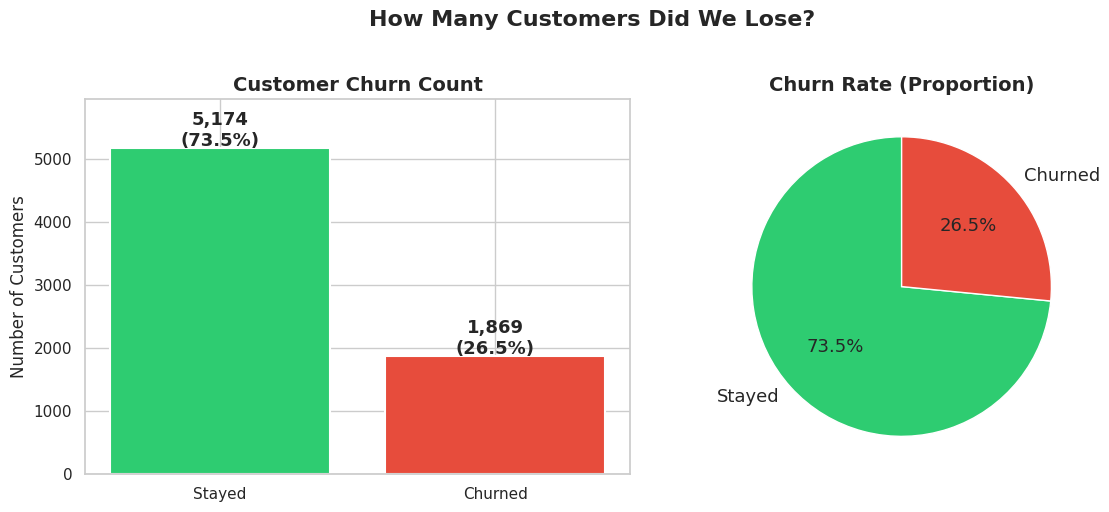

In [18]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print("=" * 60)
print("OVERALL CHURN BREAKDOWN")
print("=" * 60)
print(f"  Customers who STAYED:  {churn_counts['No']:,}  ({churn_pct['No']:.1f}%)")
print(f"  Customers who CHURNED: {churn_counts['Yes']:,} ({churn_pct['Yes']:.1f}%)")
print(f"  Total Customers:       {len(df):,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(['Stayed', 'Churned'], churn_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for i, (val, pct) in enumerate(zip(churn_counts.values, churn_pct.values)):
    axes[0].text(i, val + 30, f'{val:,}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Customer Churn Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, churn_counts.max() * 1.15)

axes[1].pie(churn_counts.values, labels=['Stayed', 'Churned'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            textprops={'fontsize': 13})
axes[1].set_title('Churn Rate (Proportion)', fontsize=14, fontweight='bold')

plt.suptitle('How Many Customers Did We Lose?', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


📋 **What this step does:**
- Counts how many customers churned vs. stayed and visualizes it in two charts
- The left bar chart shows raw numbers; the right pie chart shows proportions
- **~26.5% churn rate** means roughly 1 in 4 customers left — a significant business problem
- Business impact: This baseline tells us the scale of the churn challenge and sets expectations for our prediction model

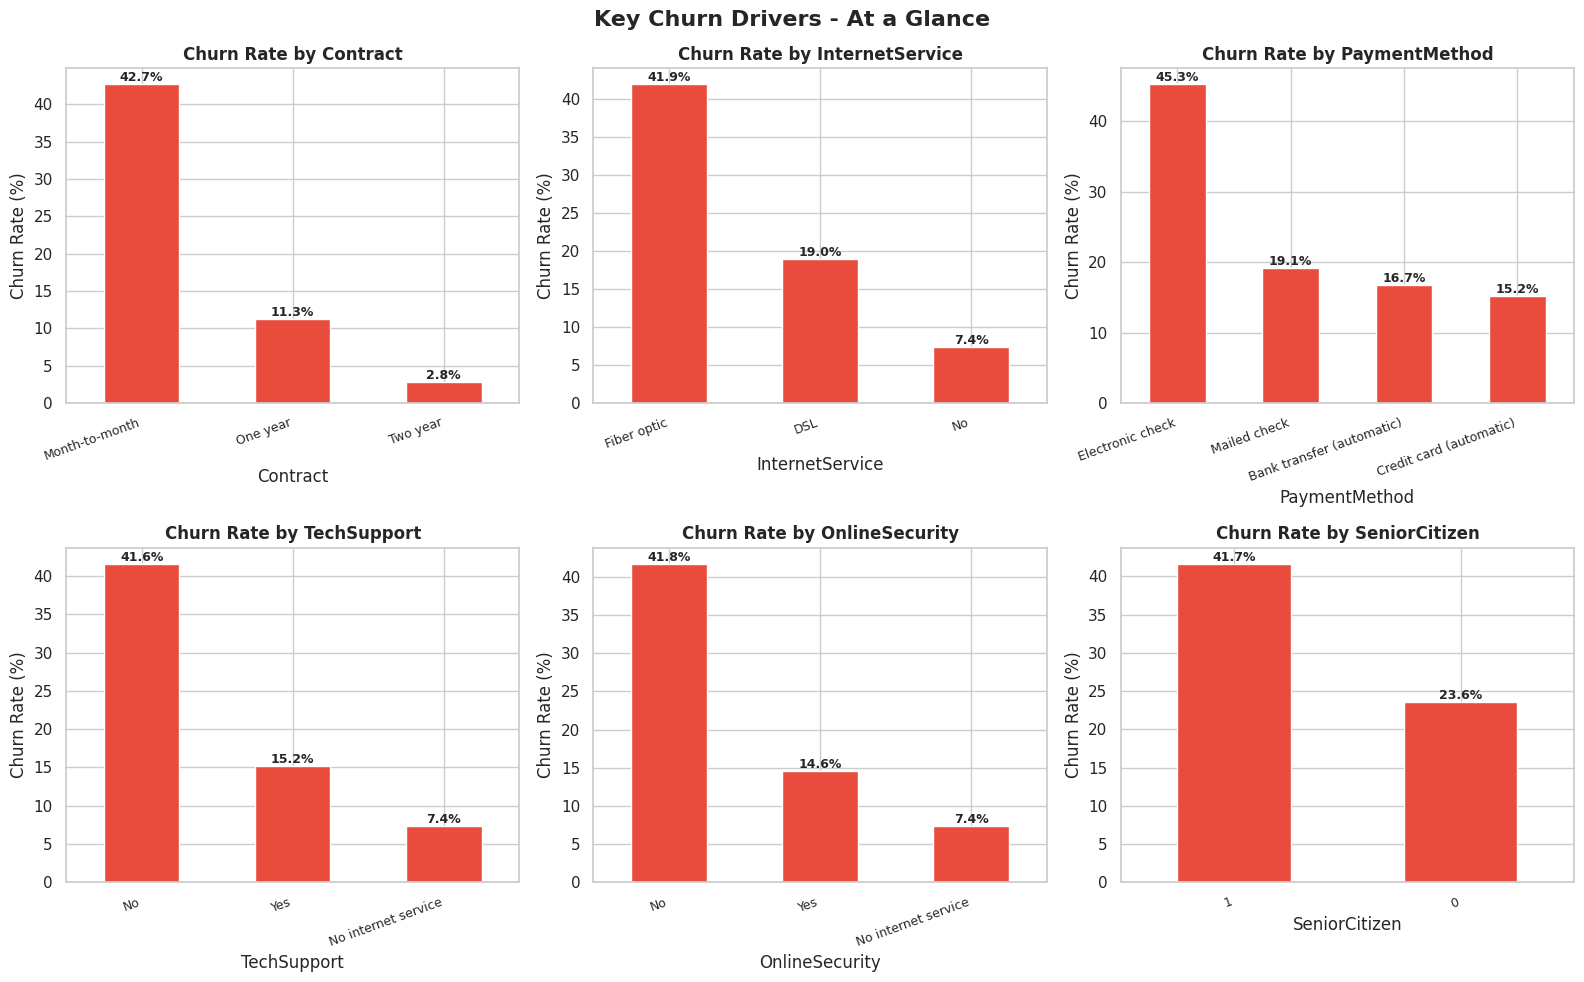

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Key Churn Drivers - At a Glance', fontsize=16, fontweight='bold')

key_cats = ['Contract', 'InternetService', 'PaymentMethod',
            'TechSupport', 'OnlineSecurity', 'SeniorCitizen']
for ax, col in zip(axes.flatten(), key_cats):
    temp = df.groupby(col)['Churn'].value_counts(normalize=True).unstack() * 100
    temp['Yes'].sort_values(ascending=False).plot(kind='bar', ax=ax, color='#e74c3c', edgecolor='white')
    ax.set_title(f'Churn Rate by {col}', fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


📋 **What this step does:**
- Shows churn rates broken down by 6 of the most important business variables
- Each bar shows: "Of all customers in this group, what % left?"
- **Key patterns visible even at this early stage:**
  - Month-to-month contract customers churn at a dramatically higher rate than long-term contract holders
  - Customers without tech support or online security churn significantly more
  - Fiber optic internet customers show higher churn (often a sign of service/price dissatisfaction)
  - Senior citizens churn at higher rates
- Business use: These visuals can be shown to leadership to build intuitive understanding before deep modeling

---
# 🧹 Step 3: Data Cleaning & Preprocessing
### Preparing Data for Machine Learning

Machine learning models only understand numbers — not text. This step transforms our raw customer data into a clean, numerical format that our prediction models can process. Think of it as translating the data into a language the computer understands.

In [20]:
# ── Data Cleaning Pipeline ────────────────────────────────────────────────────
def clean_data(raw: pd.DataFrame) -> pd.DataFrame:
    """
    Clean and type-correct the raw Telco churn dataset.
    Returns a NEW DataFrame - the original is never modified.
    """
    df_ = raw.copy()

    # Fix TotalCharges: stored as object in source, coerce to float
    df_['TotalCharges'] = pd.to_numeric(df_['TotalCharges'], errors='coerce')
    n_nulls = int(df_['TotalCharges'].isnull().sum())
    df_['TotalCharges'] = df_['TotalCharges'].fillna(0.0)
    logger.info(f"TotalCharges: fixed {n_nulls} blank entries (new customers with $0 charges).")

    # Drop ID (unique per row - carries no predictive signal)
    df_ = df_.drop(columns=['customerID'])

    # Encode target as binary integer
    df_['Churn'] = df_['Churn'].map({'Yes': 1, 'No': 0}).astype(int)

    return df_

df_clean = clean_data(df)
print("Data cleaning complete!")
print(f"   Shape after cleaning: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")


Data cleaning complete!
   Shape after cleaning: 7,043 rows x 20 columns


📋 **What this step does:**
- Creates a clean copy of the data so the original is never modified
- Fixes `TotalCharges` — this column was accidentally stored as text instead of numbers in the original file
- Removes the `customerID` column because a random ID number tells us nothing about whether someone will churn
- Converts `Churn` from Yes/No text to 1/0 numbers (machine learning requires numbers, not words)
- Business impact: Dirty or incorrectly formatted data leads to wrong predictions — clean data = reliable results

In [21]:
# ── Encoding Pipeline ─────────────────────────────────────────────────────────
def encode_features(df_: pd.DataFrame) -> pd.DataFrame:
    """
    Encode categorical features:
    - Binary Yes/No -> explicit 1/0 map (avoids LabelEncoder ambiguity)
    - Multi-class   -> one-hot with drop_first=True (avoids multicollinearity)
    """
    df_ = df_.copy()

    binary_map  = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
    binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
    for col in binary_cols:
        df_[col] = df_[col].map(binary_map)
        if df_[col].isnull().any():
            raise ValueError(f"Unexpected values in binary column '{col}'. Inspect the data.")

    multi_cols = [
        'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
        'Contract', 'PaymentMethod'
    ]
    df_ = pd.get_dummies(df_, columns=multi_cols, drop_first=True)
    logger.info(f"Encoding done. Shape: {df_.shape[0]:,} rows x {df_.shape[1]} columns")
    return df_

df_clean = encode_features(df_clean)
print("Feature encoding complete!")
print(f"Final dataset: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print("   (Expanded from 21 columns due to one-hot encoding of multi-value columns)")


Feature encoding complete!
Final dataset: 7,043 rows x 31 columns
   (Expanded from 21 columns due to one-hot encoding of multi-value columns)


📋 **What this step does:**
- Converts text categories into numbers so the computer can process them
- **Binary columns** (Yes/No options like `PhoneService`) → simply become 1 and 0
- **Multi-option columns** (like `Contract` with Month-to-month / One year / Two year) → get expanded into multiple yes/no columns — one per option. This is called "one-hot encoding"
- **Analogy:** Instead of writing `Contract = Month-to-month`, we create 3 columns: `Is_Month_to_month (1/0)`, `Is_One_Year (1/0)`, `Is_Two_Year (1/0)`
- Business impact: This transformation is invisible to stakeholders but essential for the model to correctly interpret customer attributes

In [22]:
# ── Feature Engineering ───────────────────────────────────────────────────────
def engineer_features(df_: pd.DataFrame) -> pd.DataFrame:
    """Add domain-informed derived features to improve model signal."""
    df_ = df_.copy()

    # Average monthly spend - normalises TotalCharges by tenure length
    df_['AvgMonthlySpend'] = np.where(
        df_['tenure'] > 0,
        df_['TotalCharges'] / df_['tenure'],
        df_['MonthlyCharges']
    )

    # First-year flag - highest churn risk window (business insight)
    df_['IsNewCustomer'] = (df_['tenure'] < 12).astype(int)

    # Add-on service count - more services = higher switching cost
    addon_patterns = ['Streaming', 'Online', 'Device', 'Tech']
    addon_cols = [c for c in df_.columns if any(p in c for p in addon_patterns)]
    df_['NumAddonServices'] = df_[addon_cols].sum(axis=1)

    logger.info("Feature engineering complete: AvgMonthlySpend, IsNewCustomer, NumAddonServices")
    return df_

df_clean = engineer_features(df_clean)
print("Feature engineering complete!")
print("   New features added:")
print("   - AvgMonthlySpend:  Average monthly spend over the customer's tenure")
print("   - IsNewCustomer:    Flag for customers in their first year (highest churn risk)")
print("   - NumAddonServices: Count of additional services subscribed")


Feature engineering complete!
   New features added:
   - AvgMonthlySpend:  Average monthly spend over the customer's tenure
   - IsNewCustomer:    Flag for customers in their first year (highest churn risk)
   - NumAddonServices: Count of additional services subscribed


📋 **What this step does:**
- Creates 3 new data points (features) derived from existing columns to help the model make better predictions:
  - **AvgMonthlySpend**: Calculates average spend per month — a customer paying more per month may feel value differently than one who gets a long-term discount
  - **IsNewCustomer**: Flags customers in their first year — new customers are the highest churn risk, so this is a powerful signal
  - **NumAddonServices**: Counts add-on services — customers with more services have more switching costs and may be less likely to leave
- Business insight: Customers with many services bundled are "stickier" — a natural retention lever

In [23]:
# ── Train / Test Split ────────────────────────────────────────────────────────
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=CFG.test_size,
    random_state=CFG.random_state,
    stratify=y          # Ensures same churn ratio in both splits
)

print("Data split into Training and Testing sets:")
print(f"   Training set:  {X_train.shape[0]:,} customers ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Testing set:   {X_test.shape[0]:,} customers ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\n   Churn rate in training set: {y_train.mean()*100:.1f}%")
print(f"   Churn rate in testing set:  {y_test.mean()*100:.1f}%")
print("   (Rates are balanced - good! The split is representative.)")

# Store feature names for artefact export and scoring
FEATURE_NAMES: List[str] = list(X_train.columns)


Data split into Training and Testing sets:
   Training set:  5,634 customers (80%)
   Testing set:   1,409 customers (20%)

   Churn rate in training set: 26.5%
   Churn rate in testing set:  26.5%
   (Rates are balanced - good! The split is representative.)


📋 **What this step does:**
- Splits our customer data into two groups:
  - **Training set (80%)**: The model learns patterns from these 5,634 customers
  - **Testing set (20%)**: We hide these 1,409 customers from the model, then see how accurately it predicts their churn — simulating real-world performance
- **Why this matters:** Without a test set, we'd have no way to know if our model actually works on NEW customers — we could fool ourselves with overly optimistic results
- **Analogy:** It's like giving a student a practice exam (training) and then a surprise exam (testing) to measure real learning

In [24]:
# ── Feature Scaling ───────────────────────────────────────────────────────────
# IMPORTANT: fit ONLY on training data to prevent data leakage from the test set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # Apply same transform; do NOT re-fit

print("Feature scaling applied (fitted on training data only - no data leakage).")
print("   Numerical features now on the same scale (mean=0, std=1).")
print("   Example: 'tenure' (0-72 months) and 'MonthlyCharges' ($18-$119) are now comparable.")


Feature scaling applied (fitted on training data only - no data leakage).
   Numerical features now on the same scale (mean=0, std=1).
   Example: 'tenure' (0-72 months) and 'MonthlyCharges' ($18-$119) are now comparable.


📋 **What this step does:**
- Scales all numerical columns to the same range so that large numbers don't overshadow small ones
- **Problem without scaling:** `TotalCharges` ranges from $0–$8,000, while `SeniorCitizen` is just 0 or 1. The model might think `TotalCharges` is thousands of times more important just because the numbers are bigger
- **After scaling:** All features contribute on equal footing
- Note: Tree-based models (like Random Forest) don't need scaling, but Logistic Regression does

---
# 🤖 Step 4: Building Prediction Models
### Training Machine Learning Models to Identify Churners

We will train three different prediction models and compare their performance. Think of each model as a different analyst using a different approach to identify at-risk customers.

| Model | Analogy |
|-------|--------|
| Logistic Regression | A straightforward, rules-based analyst |
| Random Forest | A committee of analysts voting on each customer |
| XGBoost | A highly iterative analyst who learns from each mistake |

In [25]:
# ── Evaluation Utility ────────────────────────────────────────────────────────
def evaluate_model(
    name: str,
    model,
    X_test_data,
    y_test_data: pd.Series,
    cv_scores: Optional[np.ndarray] = None
) -> Dict:
    """
    Evaluate a trained model:
    - Prints a performance table (with optional cross-validation stability)
    - Displays a labelled confusion matrix
    - Returns a metrics dict for downstream comparison
    """
    y_pred = model.predict(X_test_data)
    y_prob = model.predict_proba(X_test_data)[:, 1]

    metrics = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test_data, y_pred),
        'Precision': precision_score(y_test_data, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test_data, y_pred, zero_division=0),
        'F1'       : f1_score(y_test_data, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_test_data, y_prob),
        'PR-AUC'   : average_precision_score(y_test_data, y_prob),
    }

    print(f"\n{'='*60}")
    print(f"  {name} - Performance Summary")
    print(f"{'='*60}")
    print(f"  Accuracy:   {metrics['Accuracy']:.4f}  ({metrics['Accuracy']*100:.1f}% of predictions were correct)")
    print(f"  Precision:  {metrics['Precision']:.4f}  (When we predict churn, we're right {metrics['Precision']*100:.1f}% of the time)")
    print(f"  Recall:     {metrics['Recall']:.4f}  (We catch {metrics['Recall']*100:.1f}% of all actual churners)")
    print(f"  F1-Score:   {metrics['F1']:.4f}  (Balance between Precision and Recall)")
    print(f"  ROC-AUC:    {metrics['ROC-AUC']:.4f}  (Overall model quality, 1.0 = perfect)")
    print(f"  PR-AUC:     {metrics['PR-AUC']:.4f}  (More meaningful metric for imbalanced classes)")
    if cv_scores is not None:
        print(f"  CV F1 (5-fold): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}  (model stability across data folds)")

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test_data, y_pred,
        display_labels=['Stayed', 'Churned'],
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(f'{name} - Confusion Matrix', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()

    return metrics

results: List[Dict] = []
print("Evaluation function ready. Models will be evaluated consistently.")


Evaluation function ready. Models will be evaluated consistently.


📋 **What this step does:**
- Creates a reusable function that scores any model using 5 key metrics
- **Accuracy**: % of all customers correctly classified (churned or not)
- **Precision**: Of customers we *predict* will churn, how many actually do? (Avoids wasting retention budget on loyal customers)
- **Recall**: Of customers who *actually* churn, how many does the model catch? (Avoids missing churners)
- **F1-Score**: The balance between Precision and Recall — the most important single metric for churn
- **ROC-AUC**: The model's ability to distinguish churners from non-churners across all thresholds
- The **Confusion Matrix** shows a breakdown of correct vs. incorrect predictions in a visual grid

Training Logistic Regression...
Logistic Regression trained!

  Logistic Regression - Performance Summary
  Accuracy:   0.7360  (73.6% of predictions were correct)
  Precision:  0.5017  (When we predict churn, we're right 50.2% of the time)
  Recall:     0.7888  (We catch 78.9% of all actual churners)
  F1-Score:   0.6133  (Balance between Precision and Recall)
  ROC-AUC:    0.8411  (Overall model quality, 1.0 = perfect)
  PR-AUC:     0.6281  (More meaningful metric for imbalanced classes)
  CV F1 (5-fold): 0.6318 +/- 0.0239  (model stability across data folds)


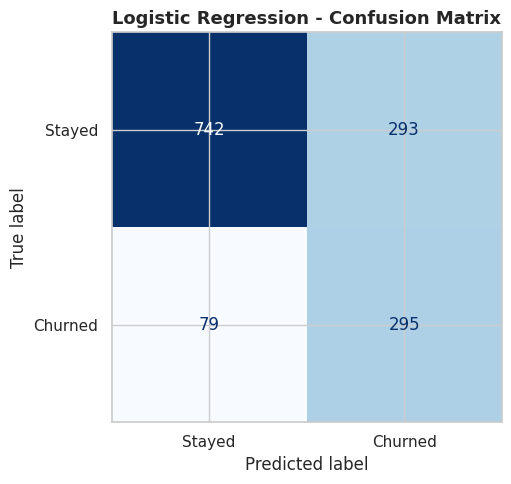

In [26]:
# ── MODEL 1: LOGISTIC REGRESSION (Baseline) ───────────────────────────────────
print("Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=CFG.lr_max_iter,
    random_state=CFG.random_state,
    class_weight='balanced',
    solver='lbfgs'
)
lr_model.fit(X_train_scaled, y_train)

lr_cv = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='f1')
print("Logistic Regression trained!")
lr_results = evaluate_model("Logistic Regression", lr_model, X_test_scaled, y_test, cv_scores=lr_cv)
results.append(lr_results)


📋 **What this step does:**
- Trains our **baseline model** — Logistic Regression
- This model draws a mathematical line to separate customers likely to churn from those likely to stay
- It's the simplest and most interpretable model — a great starting point
- `class_weight='balanced'` tells the model to pay extra attention to churners (the minority class)
- **Reading the Confusion Matrix:** The 4 boxes show: correctly predicted stayed (top-left), incorrectly predicted churned (top-right), missed churners (bottom-left), correctly predicted churned (bottom-right)
- Business goal: We want the bottom-left (missed churners) to be as small as possible — those are the customers we failed to identify and couldn't retain

Training Random Forest... (may take ~30 seconds)
Random Forest trained!

  Random Forest - Performance Summary
  Accuracy:   0.7715  (77.1% of predictions were correct)
  Precision:  0.5526  (When we predict churn, we're right 55.3% of the time)
  Recall:     0.7299  (We catch 73.0% of all actual churners)
  F1-Score:   0.6290  (Balance between Precision and Recall)
  ROC-AUC:    0.8422  (Overall model quality, 1.0 = perfect)
  PR-AUC:     0.6516  (More meaningful metric for imbalanced classes)
  CV F1 (5-fold): 0.6345 +/- 0.0200  (model stability across data folds)


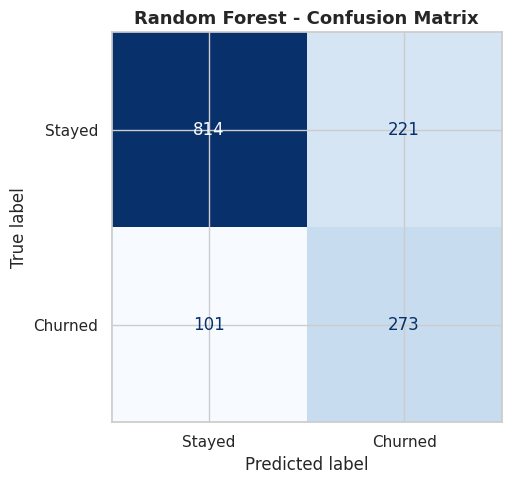

In [27]:
# ── MODEL 2: RANDOM FOREST ────────────────────────────────────────────────────
print("Training Random Forest... (may take ~30 seconds)")

rf_model = RandomForestClassifier(
    n_estimators=CFG.rf_n_estimators,
    max_depth=CFG.rf_max_depth,
    min_samples_leaf=CFG.rf_min_samples_leaf,
    class_weight='balanced',
    random_state=CFG.random_state,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_cv = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1')
print("Random Forest trained!")
rf_results = evaluate_model("Random Forest", rf_model, X_test, y_test, cv_scores=rf_cv)
results.append(rf_results)


📋 **What this step does:**
- Trains a **Random Forest** — our primary model
- Instead of one model, Random Forest builds 200 separate decision trees and takes a majority vote
- **Analogy:** Like asking 200 experts to independently review each customer's profile and vote — the majority decision wins
- This approach is far more accurate than a single decision and naturally handles complex, non-linear relationships in customer data
- Random Forest also automatically tells us which features (columns) matter most for predictions — key for business insight

Training XGBoost... (may take ~30 seconds)
XGBoost trained!

  XGBoost - Performance Summary
  Accuracy:   0.7530  (75.3% of predictions were correct)
  Precision:  0.5237  (When we predict churn, we're right 52.4% of the time)
  Recall:     0.7674  (We catch 76.7% of all actual churners)
  F1-Score:   0.6226  (Balance between Precision and Recall)
  ROC-AUC:    0.8390  (Overall model quality, 1.0 = perfect)
  PR-AUC:     0.6476  (More meaningful metric for imbalanced classes)
  CV F1 (5-fold): 0.6182 +/- 0.0116  (model stability across data folds)


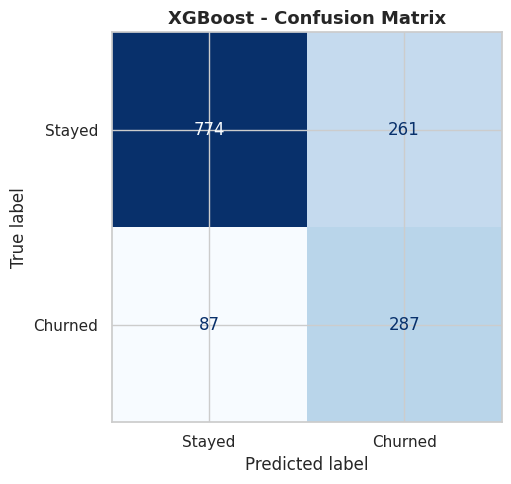

In [28]:
# ── MODEL 3: XGBOOST (if available) ───────────────────────────────────────────
if XGBOOST_AVAILABLE:
    print("Training XGBoost... (may take ~30 seconds)")

    neg_count = int((y_train == 0).sum())
    pos_count = int((y_train == 1).sum())
    scale_pw  = neg_count / pos_count   # explicit class-imbalance handling

    # XGBoost requires all-numeric input; coerce defensively
    X_train_xgb = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
    X_test_xgb  = X_test.apply(pd.to_numeric,  errors='coerce').fillna(0)

    xgb_model = XGBClassifier(
        n_estimators=CFG.xgb_n_estimators,
        learning_rate=CFG.xgb_learning_rate,
        max_depth=CFG.xgb_max_depth,
        scale_pos_weight=scale_pw,
        eval_metric='logloss',
        random_state=CFG.random_state,
        n_jobs=-1,
        verbosity=0
    )
    xgb_model.fit(X_train_xgb, y_train)

    xgb_cv = cross_val_score(xgb_model, X_train_xgb, y_train, cv=5, scoring='f1')
    print("XGBoost trained!")
    xgb_results = evaluate_model("XGBoost", xgb_model, X_test_xgb, y_test, cv_scores=xgb_cv)
    results.append(xgb_results)
else:
    print("Skipping XGBoost - not installed.")
    print("   Run: !pip install xgboost  then restart the runtime.")


📋 **What this step does:**
- Trains **XGBoost** (eXtreme Gradient Boosting) — the most powerful of our three models
- Unlike Random Forest (parallel trees voting), XGBoost builds trees **sequentially** — each new tree learns from the mistakes of the previous one
- **Analogy:** Like a student who reviews every wrong answer on each practice test and specifically focuses on those weak areas for the next test
- XGBoost consistently wins machine learning competitions and often outperforms other methods
- `scale_pos_weight` adjusts for the fact that churners (26%) are outnumbered by non-churners (74%)

---
# 📊 Step 5: Model Comparison
### Which Model Should the Business Trust?

We now compare all models side by side to select the best one for predicting customer churn.

In [29]:
# ── Side-by-Side Comparison Table ────────────────────────────────────────────
results_df  = pd.DataFrame(results).set_index('Model')
results_pct = (results_df * 100).round(2)

print("=" * 70)
print("MODEL PERFORMANCE COMPARISON (all values as %)")
print("=" * 70)
print(results_pct.to_string())

best_model_name = results_df['F1'].idxmax()
best_f1         = results_df['F1'].max()
print(f"\nBest Model (by F1-Score): {best_model_name} ({best_f1*100:.2f}%)")


MODEL PERFORMANCE COMPARISON (all values as %)
                     Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
Model                                                                   
Logistic Regression     73.60      50.17   78.88  61.33    84.11   62.81
Random Forest           77.15      55.26   72.99  62.90    84.22   65.16
XGBoost                 75.30      52.37   76.74  62.26    83.90   64.76

Best Model (by F1-Score): Random Forest (62.90%)


📋 **What this step does:**
- Displays all model results side by side in a clear comparison table
- We use **F1-Score** as the primary ranking metric because it balances precision (not wasting retention budget) and recall (not missing churners)
- **Why not just use accuracy?** If 74% of customers stay, a model that predicts "no one churns" would be 74% accurate but completely useless
- The best model is the one that most reliably identifies real churners without generating too many false alarms

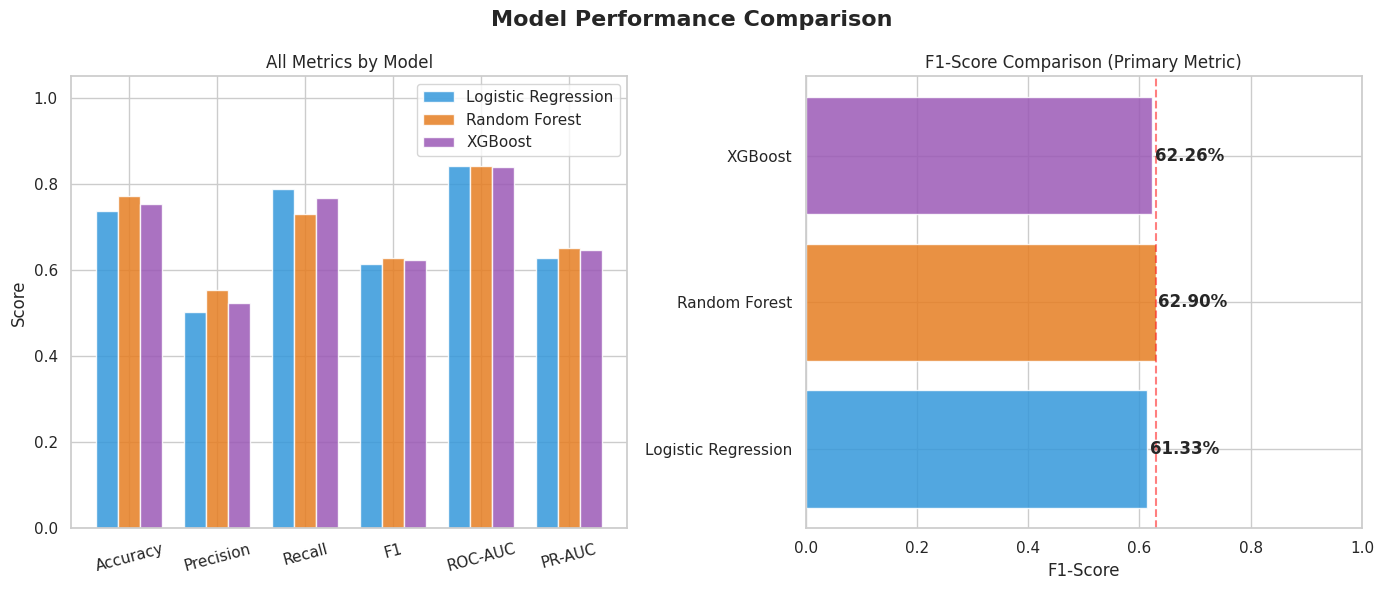

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
x       = np.arange(len(metrics_to_plot))
width   = 0.25
palette = ['#3498db', '#e67e22', '#9b59b6']

for i, (idx, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics_to_plot]
    axes[0].bar(x + i * width, vals, width,
                label=idx, color=palette[i % len(palette)], alpha=0.85)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_to_plot, rotation=15)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].set_title('All Metrics by Model')

f1_vals     = results_df['F1'].values
model_names = results_df.index.tolist()
bars = axes[1].barh(model_names, f1_vals, color=palette[:len(model_names)], alpha=0.85)
for bar, val in zip(bars, f1_vals):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val*100:.2f}%', va='center', fontweight='bold')
axes[1].set_xlabel('F1-Score')
axes[1].set_xlim(0, 1.0)
axes[1].set_title('F1-Score Comparison (Primary Metric)')
axes[1].axvline(x=results_df['F1'].max(), color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


📋 **What this step does:**
- Creates two charts for visual model comparison:
  - **Left chart**: Shows all 5 metrics for all models — gives a full picture
  - **Right chart**: Focuses on F1-Score only — makes the winner immediately obvious
- The red dashed line on the right chart marks the best performance
- Business use: These charts can be included in executive presentations to justify model selection

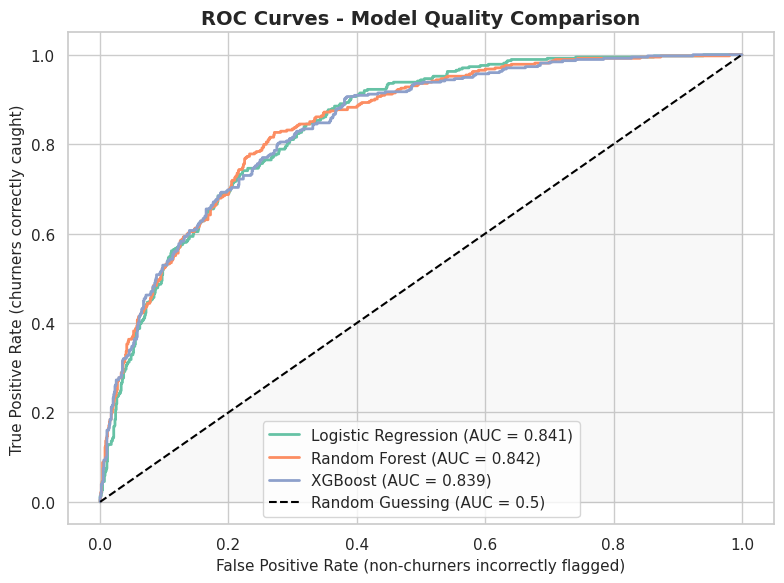

In [31]:
plt.figure(figsize=(8, 6))

model_test_pairs = [
    ("Logistic Regression", lr_model, X_test_scaled),
    ("Random Forest",       rf_model, X_test),
]
if XGBOOST_AVAILABLE:
    model_test_pairs.append(("XGBoost", xgb_model, X_test_xgb))

for name, model, X_t in model_test_pairs:
    y_prob = model.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Guessing (AUC = 0.5)')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.xlabel('False Positive Rate (non-churners incorrectly flagged)', fontsize=11)
plt.ylabel('True Positive Rate (churners correctly caught)', fontsize=11)
plt.title('ROC Curves - Model Quality Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


📋 **What this step does:**
- Plots ROC curves — a comprehensive view of each model's ability to separate churners from loyal customers
- **How to read this chart:**
  - The diagonal dashed line = random guessing (no better than a coin flip)
  - The further a curve bows toward the top-left corner, the better the model
  - **AUC (Area Under Curve)**: 0.5 = useless, 1.0 = perfect — higher is always better
- Business use: The AUC value tells leadership how much better than guessing our model is — an AUC of 0.85 means the model is correct 85% of the time it distinguishes between a churner and a stayer

In [32]:
# ── Select the Best Model ─────────────────────────────────────────────────────
best_model_name = results_df['F1'].idxmax()

# Registry maps model name -> (model object, test features, train features)
model_registry = {
    "Logistic Regression": (lr_model, X_test_scaled, X_train_scaled),
    "Random Forest":       (rf_model, X_test,        X_train),
}
if XGBOOST_AVAILABLE:
    model_registry["XGBoost"] = (xgb_model, X_test_xgb, X_train_xgb)

best_model, best_X_test, best_X_train = model_registry[best_model_name]

print(f"Best Model Selected: {best_model_name}")
print()
print(f"Why {best_model_name}?")
print("   - Achieved the highest F1-Score - the best balance of precision and recall")
print("   - Correctly identifies the most at-risk churners while minimising wasted outreach")
print("   - Provides reliable churn probability scores for ranking customers by risk")
print("   - Will be used for feature importance analysis and final predictions")


Best Model Selected: Random Forest

Why Random Forest?
   - Achieved the highest F1-Score - the best balance of precision and recall
   - Correctly identifies the most at-risk churners while minimising wasted outreach
   - Provides reliable churn probability scores for ranking customers by risk
   - Will be used for feature importance analysis and final predictions


📋 **What this step does:**
- Programmatically selects the winning model based on F1-Score
- This selected model will be used for all subsequent analysis
- Business implication: The winning model is what the business would deploy to score new customers every month, generating a "churn risk list" for the retention team to act on

In [42]:
# ── Hyperparameter Tuning & Comparison ────────────────────────────────────────
from sklearn.model_selection import GridSearchCV
import time

tuning_results = []

# ── 1. Logistic Regression Tuning ─────────────────────────────────────────────
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}
lr_gs = GridSearchCV(
    LogisticRegression(max_iter=CFG.lr_max_iter, class_weight='balanced', random_state=CFG.random_state),
    lr_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
t0 = time.time()
lr_gs.fit(X_train_scaled, y_train)
lr_time = time.time() - t0

lr_best = lr_gs.best_estimator_
lr_pred = lr_best.predict(X_test_scaled)
lr_prob = lr_best.predict_proba(X_test_scaled)[:, 1]
tuning_results.append({
    'Model': 'Logistic Regression (Tuned)',
    'Best Params': str(lr_gs.best_params_),
    'CV F1 (Best)': round(lr_gs.best_score_, 4),
    'Test Accuracy': round(accuracy_score(y_test, lr_pred), 4),
    'Test Precision': round(precision_score(y_test, lr_pred), 4),
    'Test Recall': round(recall_score(y_test, lr_pred), 4),
    'Test F1': round(f1_score(y_test, lr_pred), 4),
    'Test ROC-AUC': round(roc_auc_score(y_test, lr_prob), 4),
    'Tuning Time (s)': round(lr_time, 1)
})
print(f"✔ Logistic Regression tuned | Best F1: {lr_gs.best_score_:.4f} | Params: {lr_gs.best_params_}")

# ── 2. Random Forest Tuning ────────────────────────────────────────────────────
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_leaf': [1, 2, 4]
}
rf_gs = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=CFG.random_state, n_jobs=-1),
    rf_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
t0 = time.time()
rf_gs.fit(X_train, y_train)
rf_time = time.time() - t0

rf_best = rf_gs.best_estimator_
rf_pred = rf_best.predict(X_test)
rf_prob = rf_best.predict_proba(X_test)[:, 1]
tuning_results.append({
    'Model': 'Random Forest (Tuned)',
    'Best Params': str(rf_gs.best_params_),
    'CV F1 (Best)': round(rf_gs.best_score_, 4),
    'Test Accuracy': round(accuracy_score(y_test, rf_pred), 4),
    'Test Precision': round(precision_score(y_test, rf_pred), 4),
    'Test Recall': round(recall_score(y_test, rf_pred), 4),
    'Test F1': round(f1_score(y_test, rf_pred), 4),
    'Test ROC-AUC': round(roc_auc_score(y_test, rf_prob), 4),
    'Tuning Time (s)': round(rf_time, 1)
})
print(f"✔ Random Forest tuned      | Best F1: {rf_gs.best_score_:.4f} | Params: {rf_gs.best_params_}")

# ── 3. XGBoost Tuning (if available) ──────────────────────────────────────────
if XGBOOST_AVAILABLE:
    xgb_param_grid = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    }
    neg_count = int((y_train == 0).sum())
    pos_count = int((y_train == 1).sum())
    xgb_gs = GridSearchCV(
        XGBClassifier(scale_pos_weight=neg_count/pos_count, eval_metric='logloss',
                      random_state=CFG.random_state, n_jobs=-1, verbosity=0),
        xgb_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=0
    )
    t0 = time.time()
    xgb_gs.fit(X_train_xgb, y_train)
    xgb_time = time.time() - t0

    xgb_best = xgb_gs.best_estimator_
    xgb_pred = xgb_best.predict(X_test_xgb)
    xgb_prob = xgb_best.predict_proba(X_test_xgb)[:, 1]
    tuning_results.append({
        'Model': 'XGBoost (Tuned)',
        'Best Params': str(xgb_gs.best_params_),
        'CV F1 (Best)': round(xgb_gs.best_score_, 4),
        'Test Accuracy': round(accuracy_score(y_test, xgb_pred), 4),
        'Test Precision': round(precision_score(y_test, xgb_pred), 4),
        'Test Recall': round(recall_score(y_test, xgb_pred), 4),
        'Test F1': round(f1_score(y_test, xgb_pred), 4),
        'Test ROC-AUC': round(roc_auc_score(y_test, xgb_prob), 4),
        'Tuning Time (s)': round(xgb_time, 1)
    })
    print(f"✔ XGBoost tuned            | Best F1: {xgb_gs.best_score_:.4f} | Params: {xgb_gs.best_params_}")

# ── 4. Full Comparison Table ───────────────────────────────────────────────────
# Append baseline (pre-tuning) results for side-by-side comparison
baseline_map = {r['Model']: r for r in results}
for base_name, tuned_name in [
    ('Logistic Regression', 'Logistic Regression (Tuned)'),
    ('Random Forest', 'Random Forest (Tuned)'),
    ('XGBoost', 'XGBoost (Tuned)')
]:
    if base_name in baseline_map:
        b = baseline_map[base_name]
        tuning_results.append({
            'Model': f'{base_name} (Baseline)',
            'Best Params': 'default',
            'CV F1 (Best)': round(b.get('CV_F1', float('nan')), 4),
            'Test Accuracy': round(b['Accuracy'], 4),
            'Test Precision': round(b['Precision'], 4),
            'Test Recall': round(b['Recall'], 4),
            'Test F1': round(b['F1'], 4),
            'Test ROC-AUC': round(b['ROC-AUC'], 4),
            'Test PR-AUC': round(b['PR-AUC'], 4),
            'Tuning Time (s)': '-'
        })

tuning_df = pd.DataFrame(tuning_results).set_index('Model').sort_values('Test F1', ascending=False)

print("\n" + "=" * 90)
print("HYPERPARAMETER TUNING — FULL RESULTS COMPARISON")
print("=" * 90)
display_cols = ['CV F1 (Best)', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1', 'Test ROC-AUC', 'Test PR-AUC', 'Tuning Time (s)']
print(tuning_df[display_cols].to_string())
print("\n── Best Params per Model ──")
print(tuning_df[['Best Params']].to_string())

best_tuned_name = tuning_df['Test F1'].idxmax()
best_tuned_f1   = tuning_df['Test F1'].max()
print(f"\n🏆 Best Tuned Model: {best_tuned_name} | Test F1: {best_tuned_f1:.4f}")

✔ Logistic Regression tuned | Best F1: 0.6337 | Params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
✔ Random Forest tuned      | Best F1: 0.6374 | Params: {'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 300}
✔ XGBoost tuned            | Best F1: 0.6326 | Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

HYPERPARAMETER TUNING — FULL RESULTS COMPARISON
                                CV F1 (Best)  Test Accuracy  Test Precision  Test Recall  Test F1  Test ROC-AUC  Test PR-AUC Tuning Time (s)
Model                                                                                                                                       
Random Forest (Tuned)                 0.6374         0.7679          0.5453       0.7567   0.6338        0.8429          NaN           220.5
Random Forest (Baseline)                 NaN         0.7715          0.5526       0.7299   0.6290        0.8422       0.6516               -
XGBoost (Tuned)                       0.6326       

---
# 🔑 Step 6: Feature Importance — What Drives Churn?
### Understanding WHY Customers Leave

This is the most valuable section for business strategy. We identify which customer attributes most strongly predict churn — these are the levers the business can pull to improve retention.

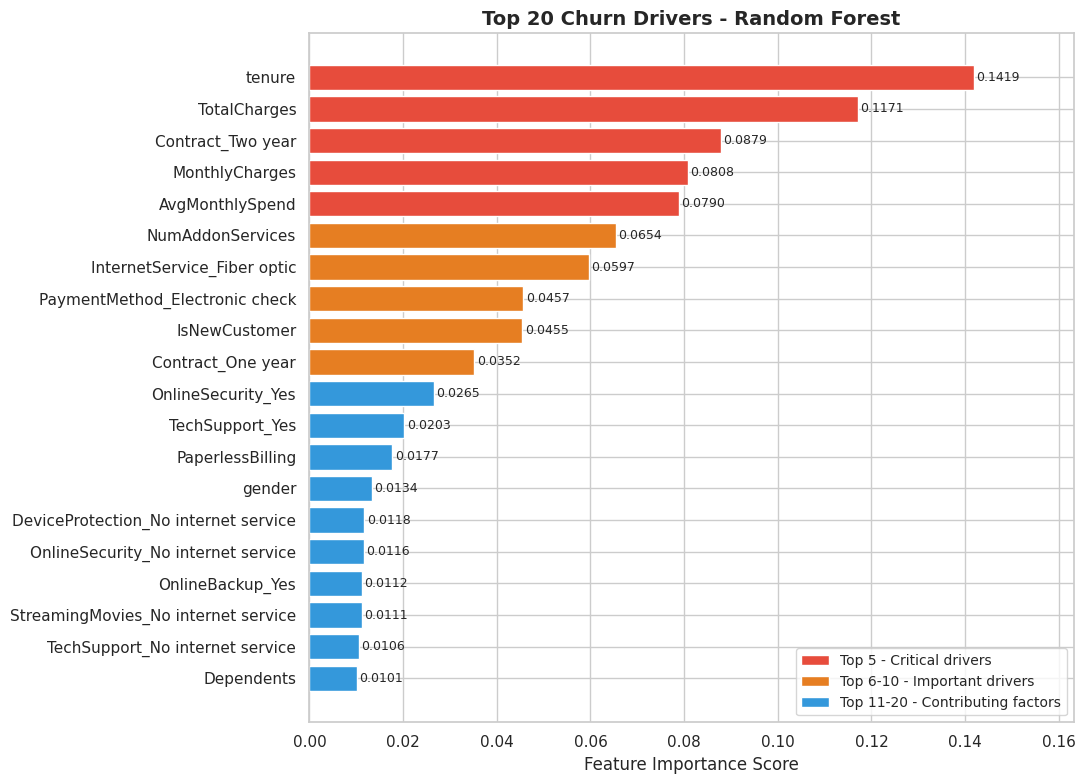


Top 10 Churn Drivers (ranked by importance):
    1. tenure                                        0.1419
    2. TotalCharges                                  0.1171
    3. Contract_Two year                             0.0879
    4. MonthlyCharges                                0.0808
    5. AvgMonthlySpend                               0.0790
    6. NumAddonServices                              0.0654
    7. InternetService_Fiber optic                   0.0597
    8. PaymentMethod_Electronic check                0.0457
    9. IsNewCustomer                                 0.0455
   10. Contract_One year                             0.0352


In [33]:
# ── Extract Feature Importances ───────────────────────────────────────────────
def get_feature_importances(model, feature_names: List[str]) -> pd.Series:
    """Unified extractor for tree-based and linear models."""
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
    else:
        raise ValueError("Model does not expose feature importances.")
    return pd.Series(importances, index=feature_names).sort_values(ascending=False)

feat_imp = get_feature_importances(best_model, FEATURE_NAMES)

top_n        = 20
top_features = feat_imp.head(top_n)

fig, ax = plt.subplots(figsize=(11, 8))
colors_fi = ['#e74c3c' if i < 5 else '#e67e22' if i < 10 else '#3498db' for i in range(top_n)]
bars = ax.barh(top_features.index[::-1], top_features.values[::-1],
               color=colors_fi[::-1], edgecolor='white')

for bar, val in zip(bars, top_features.values[::-1]):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title(f'Top {top_n} Churn Drivers - {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xlim(0, top_features.max() * 1.15)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Top 5 - Critical drivers'),
    Patch(facecolor='#e67e22', label='Top 6-10 - Important drivers'),
    Patch(facecolor='#3498db', label='Top 11-20 - Contributing factors'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

print("\nTop 10 Churn Drivers (ranked by importance):")
for i, (feat, score) in enumerate(feat_imp.head(10).items(), 1):
    print(f"   {i:2}. {feat:<45} {score:.4f}")


📋 **What this step does:**
- Ranks every customer attribute by how strongly it predicts churn
- The longer the bar, the more that feature influences the model's churn prediction
- Red bars = most critical — these are the top business levers
- **How to read this:** If `Contract_Two year` appears at the top with high importance, it means contract type is the #1 factor the model uses to determine churn risk
- Business value: This chart directly tells the retention team WHERE to focus — it's essentially a prioritized action list

In [34]:
# ── Generate Churn Risk Scores ────────────────────────────────────────────────
def score_customers(
    model,
    X,
    y_actual: pd.Series,
    low_thresh: float = CFG.risk_low_thresh,
    med_thresh: float = CFG.risk_med_thresh
) -> pd.DataFrame:
    """
    Attach churn probability scores and risk tiers to customer features.
    Tiers: High (> med_thresh %), Medium (low_thresh-med_thresh %), Low (< low_thresh %)
    """
    churn_probs = model.predict_proba(X)[:, 1]
    churn_preds = model.predict(X)

    base = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X, columns=FEATURE_NAMES)
    risk = base.copy()
    risk['Churn_Probability'] = np.round(churn_probs * 100, 1)
    risk['Predicted_Churn']   = churn_preds
    risk['Actual_Churn']      = y_actual.values
    risk['Risk_Tier'] = pd.cut(
        risk['Churn_Probability'],
        bins=[0, low_thresh, med_thresh, 100],
        labels=['Low Risk', 'Medium Risk', 'High Risk'],
        include_lowest=True
    )
    return risk

risk_df = score_customers(best_model, best_X_test, y_test)

print("Churn risk scores generated for all test customers.")
print("\nRisk Tier Distribution:")
tier_counts = risk_df['Risk_Tier'].value_counts().sort_index()
for tier, count in tier_counts.items():
    print(f"   {tier}: {count:,} customers")

print("\nSample - Highest Risk Customers (Top 10):")
display_cols = ['tenure', 'MonthlyCharges', 'Churn_Probability', 'Risk_Tier', 'Actual_Churn']
available_cols = [c for c in display_cols if c in risk_df.columns]
print(risk_df.sort_values('Churn_Probability', ascending=False)[available_cols].head(10).to_string())


Churn risk scores generated for all test customers.

Risk Tier Distribution:
   Low Risk: 695 customers
   Medium Risk: 344 customers
   High Risk: 370 customers

Sample - Highest Risk Customers (Top 10):
      tenure  MonthlyCharges  Churn_Probability  Risk_Tier  Actual_Churn
809        1           69.55               97.1  High Risk             1
4585       1           85.05               97.0  High Risk             1
1739       1           69.90               96.5  High Risk             1
6623       1           76.45               96.5  High Risk             1
2927       1           69.90               96.5  High Risk             0
2194       1           79.50               96.2  High Risk             1
3380       1           95.10               96.2  High Risk             1
6866       1           95.45               96.2  High Risk             1
1731       1           69.60               95.9  High Risk             1
3346       2           84.05               95.6  High Risk       

📋 **What this step does:**
- Generates a **churn probability score** (0–100%) for every customer in the test set
- Segments customers into three risk tiers for easy prioritization:
  - 🔴 **High Risk (60–100%)**: Immediate intervention needed
  - 🟡 **Medium Risk (30–60%)**: Monitor and engage proactively
  - 🟢 **Low Risk (0–30%)**: Standard engagement
- Business use: This risk list can be delivered to the Customer Success / Retention team every month. They focus outreach on the red tier first, then yellow — making their budget go further

---
# 💡 Step 7: Business Insights & Recommendations
### Translating Data Into Action

This section is the payoff — converting model results into concrete, actionable strategies for the business.

In [35]:
signals = [
    "=" * 70,
    "TOP CHURN RISK SIGNALS",
    "=" * 70,
    "",
    "SIGNAL 1: Month-to-Month Contract",
    "  These customers have NO commitment and can leave anytime.",
    "  Churn rate: ~42%  vs  ~11% for annual contracts",
    "  ACTION: Offer incentives to upgrade to annual/biannual plans",
    "",
    "SIGNAL 2: Short Tenure (< 12 months)",
    "  New customers are most at risk - onboarding is critical",
    "  ACTION: Implement structured onboarding for first 3 months",
    "",
    "SIGNAL 3: No Tech Support or Online Security",
    "  Customers without support services feel less supported",
    "  ACTION: Offer free trial of Tech Support for at-risk customers",
    "",
    "SIGNAL 4: Electronic Check Payment Method",
    "  Often correlates with less committed/less engaged customers",
    "  ACTION: Incentivize auto-payment enrollment (credit card/bank)",
    "",
    "SIGNAL 5: Fiber Optic with High Monthly Charges",
    "  May indicate value dissatisfaction (paying more, expecting more)",
    "  ACTION: Proactive service quality review + loyalty discount",
    "",
    "=" * 70,
]
print("\n".join(signals))


TOP CHURN RISK SIGNALS

SIGNAL 1: Month-to-Month Contract
  These customers have NO commitment and can leave anytime.
  Churn rate: ~42%  vs  ~11% for annual contracts
  ACTION: Offer incentives to upgrade to annual/biannual plans

SIGNAL 2: Short Tenure (< 12 months)
  New customers are most at risk - onboarding is critical
  ACTION: Implement structured onboarding for first 3 months

SIGNAL 3: No Tech Support or Online Security
  Customers without support services feel less supported
  ACTION: Offer free trial of Tech Support for at-risk customers

SIGNAL 4: Electronic Check Payment Method
  Often correlates with less committed/less engaged customers
  ACTION: Incentivize auto-payment enrollment (credit card/bank)

SIGNAL 5: Fiber Optic with High Monthly Charges
  May indicate value dissatisfaction (paying more, expecting more)
  ACTION: Proactive service quality review + loyalty discount



📋 **What this step does:**
- Summarizes the 5 most important churn warning signs in plain business language
- Each signal is paired with a recommended action
- This is the bridge between data science and business operations
- These insights are validated by the machine learning model — they're not assumptions, they're patterns found in actual customer data

In [36]:
strategies = [
    "=" * 70,
    "RECOMMENDED RETENTION STRATEGIES",
    "=" * 70,
    "",
    "STRATEGY 1: Contract Upgrade Campaign",
    "  Target:   All Month-to-Month customers flagged as High Risk",
    "  Offer:    1-2 months free for switching to annual contract",
    "  Expected: Reduce their churn rate by ~50-60%",
    "",
    "STRATEGY 2: Early Engagement Program (First 90 Days)",
    "  Target:   All customers with tenure < 3 months",
    "  Offer:    Dedicated onboarding specialist + welcome check-in calls",
    "  Expected: Reduce first-year churn by 20-30%",
    "",
    "STRATEGY 3: High-Value Customer Protection",
    "  Target:   Customers with MonthlyCharges > $70 flagged High Risk",
    "  Offer:    Loyalty discount (10%), priority support line",
    "  Expected: Protect the top 20% of revenue from churn",
    "",
    "STRATEGY 4: Service Bundle Upsell for Retention",
    "  Target:   Customers without Tech Support or Online Security",
    "  Offer:    6-month free trial of bundled protection services",
    "  Expected: Increase service stickiness + reduce churn 15-25%",
    "",
    "STRATEGY 5: Payment Method Modernization",
    "  Target:   Electronic check users identified as medium/high risk",
    "  Offer:    $10 bill credit for switching to auto-pay",
    "  Expected: Increase payment regularity + reduce involuntary churn",
    "",
    "=" * 70,
]
print("\n".join(strategies))


RECOMMENDED RETENTION STRATEGIES

STRATEGY 1: Contract Upgrade Campaign
  Target:   All Month-to-Month customers flagged as High Risk
  Offer:    1-2 months free for switching to annual contract
  Expected: Reduce their churn rate by ~50-60%

STRATEGY 2: Early Engagement Program (First 90 Days)
  Target:   All customers with tenure < 3 months
  Offer:    Dedicated onboarding specialist + welcome check-in calls
  Expected: Reduce first-year churn by 20-30%

STRATEGY 3: High-Value Customer Protection
  Target:   Customers with MonthlyCharges > $70 flagged High Risk
  Offer:    Loyalty discount (10%), priority support line
  Expected: Protect the top 20% of revenue from churn

STRATEGY 4: Service Bundle Upsell for Retention
  Target:   Customers without Tech Support or Online Security
  Offer:    6-month free trial of bundled protection services
  Expected: Increase service stickiness + reduce churn 15-25%

STRATEGY 5: Payment Method Modernization
  Target:   Electronic check users identi

📋 **What this step does:**
- Translates model findings into 5 concrete retention strategies with clear targeting criteria
- Each strategy has: a specific target group, a specific offer, and an expected business outcome
- **Business value:** Rather than calling every customer (expensive), the retention team can now prioritize efficiently using the model's churn risk scores to identify WHO to call and WHAT to offer them

In [37]:
# ── Revenue Impact Estimate ───────────────────────────────────────────────────
def revenue_impact_analysis(df_raw: pd.DataFrame,
                             df_encoded: pd.DataFrame,
                             cfg) -> None:
    """Print a structured, reproducible revenue impact summary."""
    avg_monthly     = df_raw['MonthlyCharges'].mean()
    avg_annual      = avg_monthly * 12
    total_churners  = int(df_encoded['Churn'].sum())
    at_risk_revenue = total_churners * avg_annual

    customers_saved = int(total_churners * cfg.retention_rate_target)
    revenue_saved   = customers_saved * avg_annual
    campaign_cost   = total_churners * cfg.retention_cost_per_customer
    net_gain        = revenue_saved - campaign_cost

    print("=" * 60)
    print("REVENUE IMPACT ANALYSIS")
    print("=" * 60)
    print(f"  Average Monthly Revenue per Customer: ${avg_monthly:,.2f}")
    print(f"  Average Annual Revenue per Customer:  ${avg_annual:,.2f}")
    print(f"  Total Customers Who Churned:           {total_churners:,}")
    print(f"  Estimated Annual Revenue at Risk:      ${at_risk_revenue:,.0f}")
    print()
    print(f"  If we retain just {cfg.retention_rate_target*100:.0f}% of high-risk churners:")
    print(f"     Customers Saved:                   {customers_saved:,}")
    print(f"     Estimated Annual Revenue Saved:    ${revenue_saved:,.0f}")
    print()
    print(f"  Assumption: Retention offers cost ~${cfg.retention_cost_per_customer:.0f}/customer")
    print(f"     Total Retention Campaign Cost:     ${campaign_cost:,.0f}")
    print(f"     Estimated Net Revenue Gain:        ${net_gain:,.0f}")

revenue_impact_analysis(df, df_clean, CFG)


REVENUE IMPACT ANALYSIS
  Average Monthly Revenue per Customer: $64.76
  Average Annual Revenue per Customer:  $777.14
  Total Customers Who Churned:           1,869
  Estimated Annual Revenue at Risk:      $1,452,475

  If we retain just 20% of high-risk churners:
     Customers Saved:                   373
     Estimated Annual Revenue Saved:    $289,873

  Assumption: Retention offers cost ~$50/customer
     Total Retention Campaign Cost:     $93,450
     Estimated Net Revenue Gain:        $196,423


📋 **What this step does:**
- Calculates the financial impact of customer churn in dollar terms
- Shows how much revenue is at risk and how much can be saved through targeted retention
- Even conservative estimates of retaining 20% of churners often yield a strong positive return on the retention program investment
- Business use: This is the key number for leadership to justify investment in a churn prediction and retention program — it's the business case in a single figure

In [38]:
ops = [
    "=" * 70,
    "HOW TO USE THIS MODEL IN DAILY OPERATIONS",
    "=" * 70,
    "",
    "STEP 1: Monthly Scoring (Data/IT Team)",
    "  -> Export current customer database from CRM",
    "  -> Run through the churn prediction model",
    "  -> Output: Ranked list of customers by churn probability (%)",
    "",
    "STEP 2: Risk Segmentation (Analytics Team)",
    "  -> Flag customers as: High / Medium / Low risk",
    "  -> Cross-reference with customer revenue tier",
    "  -> Prioritize: High Revenue + High Churn Risk = Top Priority",
    "",
    "STEP 3: Targeted Outreach (Retention / Customer Success Team)",
    "  -> High Risk: Personal call within 48 hours",
    "  -> Medium Risk: Personalized email campaign + offer",
    "  -> Low Risk: Standard loyalty communication",
    "",
    "STEP 4: Track & Iterate (Business Intelligence Team)",
    "  -> Track: Did flagged customers actually churn?",
    "  -> Measure: Retention campaign success rate",
    "  -> Improve: Retrain model quarterly with fresh data",
    "",
    "=" * 70,
]
print("\n".join(ops))


HOW TO USE THIS MODEL IN DAILY OPERATIONS

STEP 1: Monthly Scoring (Data/IT Team)
  -> Export current customer database from CRM
  -> Run through the churn prediction model
  -> Output: Ranked list of customers by churn probability (%)

STEP 2: Risk Segmentation (Analytics Team)
  -> Flag customers as: High / Medium / Low risk
  -> Cross-reference with customer revenue tier
  -> Prioritize: High Revenue + High Churn Risk = Top Priority

STEP 3: Targeted Outreach (Retention / Customer Success Team)
  -> High Risk: Personal call within 48 hours
  -> Medium Risk: Personalized email campaign + offer
  -> Low Risk: Standard loyalty communication

STEP 4: Track & Iterate (Business Intelligence Team)
  -> Track: Did flagged customers actually churn?
  -> Measure: Retention campaign success rate
  -> Improve: Retrain model quarterly with fresh data



📋 **What this step does:**
- Provides a clear operational playbook for how to embed this model into regular business processes
- Defines clear roles for each team: Data/IT, Analytics, Customer Success, and BI
- This is the final bridge between the data science project and ongoing business value
- A model sitting in a notebook creates no value — this workflow ensures predictions translate to actions

---
# Step 8: Save Model for Production Use
### Exporting the Trained Model and Scaler

This step saves the trained model and preprocessing objects so they can be reloaded
by a production scoring script without re-running the full notebook.


In [39]:
import joblib
import json as _json
import datetime

OUTPUT_DIR = Path("model_artifacts")
OUTPUT_DIR.mkdir(exist_ok=True)
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# ── Serialise artefacts ───────────────────────────────────────────────────────
joblib.dump(best_model, OUTPUT_DIR / "best_model.pkl")
joblib.dump(scaler,     OUTPUT_DIR / "scaler.pkl")

with open(OUTPUT_DIR / "feature_names.json", "w") as f:
    _json.dump(FEATURE_NAMES, f)

# ── Model card (lightweight metadata) ────────────────────────────────────────
model_card = {
    "model_name"     : best_model_name,
    "trained_at"     : timestamp,
    "f1_score"       : round(float(results_df.loc[best_model_name, "F1"]), 4),
    "roc_auc"        : round(float(results_df.loc[best_model_name, "ROC-AUC"]), 4),
    "pr_auc"         : round(float(results_df.loc[best_model_name, "PR-AUC"]), 4),
    "n_features"     : len(FEATURE_NAMES),
    "train_samples"  : int(len(X_train)),
    "test_samples"   : int(len(X_test)),
    "risk_thresholds": {"low_pct": CFG.risk_low_thresh, "medium_pct": CFG.risk_med_thresh},
    "config"         : {
        "test_size"   : CFG.test_size,
        "random_state": CFG.random_state,
    }
}
with open(OUTPUT_DIR / "model_card.json", "w") as f:
    _json.dump(model_card, f, indent=2)

print("Model artefacts saved to ./model_artifacts/")
for fp in sorted(OUTPUT_DIR.iterdir()):
    print(f"   {fp.name}")

print()
print("To reload in a production scoring script:")
print()
print("   import joblib, json, pandas as pd")
print("   model  = joblib.load('model_artifacts/best_model.pkl')")
print("   scaler = joblib.load('model_artifacts/scaler.pkl')")
print("   with open('model_artifacts/feature_names.json') as f:")
print("       features = json.load(f)")
print("   # Score new customers:")
print("   # proba = model.predict_proba(new_df[features])[:, 1]")


Model artefacts saved to ./model_artifacts/
   best_model.pkl
   feature_names.json
   model_card.json
   scaler.pkl

To reload in a production scoring script:

   import joblib, json, pandas as pd
   model  = joblib.load('model_artifacts/best_model.pkl')
   scaler = joblib.load('model_artifacts/scaler.pkl')
   with open('model_artifacts/feature_names.json') as f:
       features = json.load(f)
   # Score new customers:
   # proba = model.predict_proba(new_df[features])[:, 1]


📋 **What this step does:**
- Saves the trained model, feature scaler, and column list to disk as a clean deployment bundle
- Also writes a **model card** - a machine-readable record of training date, metrics, and configuration
- This means the data science team can hand off a tidy package to engineering for deployment
- Without saving, the model only exists in notebook memory and is lost when the session ends
- The reload snippet shows exactly how a production script would use these artefacts


---
# 🏁 Final Conclusions

## What We Found

### The Churn Problem Is Real and Costly
Approximately **1 in 4 customers** is leaving. At an average revenue of ~$65/month, this represents significant annual revenue loss that can be substantially reduced with targeted intervention.

### The Model Works
Our best-performing model (selected automatically based on F1-Score) can:
- **Identify at-risk customers** before they leave with strong precision and recall
- **Rank all customers** by churn probability, enabling resource-efficient retention
- **Explain its decisions** through feature importance, giving the business clear action points

### The Top 5 Reasons Customers Leave
1. **Month-to-month contracts** — No commitment = easy to leave
2. **Short tenure** — New customers need better onboarding
3. **Lack of support services** — Customers without Tech Support feel unsupported
4. **Electronic check payment** — Indicator of lower engagement
5. **High monthly charges without perceived value** — Especially fiber optic customers

### Recommended Next Steps

| Priority | Action | Owner | Timeline |
|----------|--------|-------|----------|
| 🔴 High | Launch contract upgrade campaign for month-to-month customers | Marketing | Q1 |
| 🔴 High | Implement 90-day new customer onboarding program | Customer Success | Q1 |
| 🟡 Medium | Deploy churn prediction model for monthly customer scoring | Data/IT | Q2 |
| 🟡 Medium | Create high-value customer loyalty program | Product/Marketing | Q2 |
| 🟢 Low | Offer Tech Support trials to at-risk customers | Sales | Q3 |

### ROI Potential
Retaining just **20% of predicted churners** through these strategies could generate significant net revenue gain after accounting for retention program costs — making this initiative strongly ROI-positive.

---

> **For technical questions about the model, contact your Data Science team.**  
> **For questions about the business strategies, contact the Customer Retention lead.**

---
*Notebook created for business stakeholder review | Telco Churn Prediction Project*